#  E-Commerce Sales & Profitability Analysis
### 1. Project Title
E-Commerce Sales, Customer & Profitability Analysis Using Python, SQL and Power BI

# 2. Problem Statement

You can use this as the official problem statement for your project:

An e-commerce company wants to understand its sales performance, profitability, customer purchasing behavior, product performance, and regional performance. Although the company has a large amount of transaction data, it lacks clear insights into which products, customers, categories, and regions are driving revenue and profit.

The objective of this project is to analyze historical e-commerce transaction data using Python and SQL and develop an interactive Power BI dashboard to identify important business trends, underperforming areas, and opportunities for improving sales and profitability.

This is much better for a BA project than saying simply "I performed EDA on an e-commerce dataset.

# 3. Business Objective

### The main objective is:

To transform raw e-commerce transaction data into actionable business insights that can help management improve sales, profitability, customer retention, and overall business performance.

### We'll specifically investigate:

## Sales
-How are sales changing over time?<br>
-Which categories generate the most revenue?<br>
-Which regions generate the most sales?<br>
-Which products perform best?<br>
## Profitability
-Which categories/products generate the highest profit?<br>
-Which products have high sales but low profit?<br>
-How does discounting affect profitability?<br>
-Are there regions with strong sales but poor profit?<br>
## Customers
-Who are the most valuable customers?<br>
-Which customers purchase frequently?<br>
-What is the average order value?<br>
-Which customer groups contribute the most revenue?<br>
## Business Performance
-What are the strongest areas of the business?<br>
-What areas need improvement?<br>
-What actions could management take?<br>

<h1>4. Key Business Questions</h1>

We'll eventually answer questions such as:

<h3>📈 Sales</h3>
1.What is the total sales revenue?<br>
2.What is the monthly/yearly sales trend?<br>
3.Which category has the highest sales?<br>
4.Which sub-category performs best?<br>
5.Which region generates the highest sales?<br>
<h3>💰 Profit</h3>
1.What is the total profit?<br>
2.Which category generates the highest profit?<br>
3.Which products have high sales but low profit?<br>
4.Which regions have low profitability?<br>
5.What is the relationship between discount and profit?<br>
<h3>👥 Customers</h3>
1.Who are the top 10 customers by sales?<br>
2.Who are the most frequent customers?<br>
3.What is the average order value?<br>
4.Which customers contribute the most profit?<br>
<h3>📦 Products</h3>
1.What are the top-selling products?<br>
2.Which products are underperforming?<br>
3.Which products generate negative profit?<br>
4.Which categories should receive more attention?<br>

# 1.Data Understanding

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv("Global_Superstore2.csv", encoding="latin1")

In [18]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [19]:
df.shape

(51290, 24)

In [20]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'City',
 'State',
 'Country',
 'Postal Code',
 'Market',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit',
 'Shipping Cost',
 'Order Priority']

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

In [22]:
df.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(0)

# 2.Data Cleaning

In [24]:
from warnings import filterwarnings
filterwarnings("ignore")

In [25]:
df_clean = df.copy()

In [26]:
df_clean["Order Date"] = pd.to_datetime(df_clean["Order Date"])
df_clean["Ship Date"] = pd.to_datetime(df_clean["Ship Date"])

In [27]:
df_clean[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [28]:
df_clean.drop(columns=["Postal Code"], inplace=True)

## Why are we dropping it?

Not because missing data should always be deleted.<br>
We're dropping it because:<br>
The column has extremely high missingness and is not essential to the business questions defined for this project.

In [29]:
df_clean.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
City              0
State             0
Country           0
Market            0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
Shipping Cost     0
Order Priority    0
dtype: int64

In [30]:
df_clean.duplicated().sum()

np.int64(0)

In [31]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  object        
 2   Order Date      51290 non-null  datetime64[ns]
 3   Ship Date       51290 non-null  datetime64[ns]
 4   Ship Mode       51290 non-null  object        
 5   Customer ID     51290 non-null  object        
 6   Customer Name   51290 non-null  object        
 7   Segment         51290 non-null  object        
 8   City            51290 non-null  object        
 9   State           51290 non-null  object        
 10  Country         51290 non-null  object        
 11  Market          51290 non-null  object        
 12  Region          51290 non-null  object        
 13  Product ID      51290 non-null  object        
 14  Category        51290 non-null  object        
 15  Su

# 2.1.Create useful Data Columns

In [32]:
df_clean["Year"] = df_clean["Order Date"].dt.year
df_clean["Month"] = df_clean["Order Date"].dt.month
df_clean["Month Name"] = df_clean["Order Date"].dt.month_name()
df_clean["Quarter"] = df_clean["Order Date"].dt.quarter

In [33]:
df_clean[["Order Date", "Year", "Month", "Month Name", "Quarter"]].head()

,Order Date,Year,Month,Month Name,Quarter
0,2012-07-31,2012,7,July,3
1,2013-02-05,2013,2,February,1
2,2013-10-17,2013,10,October,4
3,2013-01-28,2013,1,January,1
4,2013-11-05,2013,11,November,4


# 2.2 Check the Data Range

In [34]:
print("Start Date:", df_clean["Order Date"].min())
print("End Date:", df_clean["Order Date"].max())

Start Date: 2011-01-01 00:00:00
End Date: 2014-12-31 00:00:00


In [35]:
# basic numerical summary
df_clean[["Sales", "Quantity", "Discount", "Profit", "Shipping Cost"]].describe()

,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,246.490581,3.476545,0.142908,28.610982,26.375915
std,487.565361,2.278766,0.212280,174.340972,57.296804
min,0.444000,1.000000,0.000000,-6599.978000,0.000000
25%,30.758625,2.000000,0.000000,0.000000,2.610000
50%,85.053000,3.000000,0.000000,9.240000,7.790000
75%,251.053200,5.000000,0.200000,36.810000,24.450000
max,22638.480000,14.000000,0.850000,8399.976000,933.570000


# 3.Exploratory Data Analysis

#### 3.1 Overall KPIs

In [36]:
total_sales = df_clean["Sales"].sum()
total_profit = df_clean["Profit"].sum()
total_quantity = df_clean["Quantity"].sum()
total_orders = df_clean["Order ID"].nunique()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Quantity Sold:", total_quantity)
print("Total Orders:", total_orders)

Total Sales: 12642501.90988
Total Profit: 1467457.29128
Total Quantity Sold: 178312
Total Orders: 25035


In [37]:
# Calculate profit margin
profit_margin = (total_profit / total_sales) * 100
print("Profit Margin:", profit_margin, "%")

Profit Margin: 11.607332960995604 %


## 3.2 Sales by Category
Now let's ask our first real business question:<br>
> Which product categories generate the most sales?

In [38]:
category_sales = (
    df_clean.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

Category
Technology         4.744557e+06
Furniture          4.110874e+06
Office Supplies    3.787070e+06
Name: Sales, dtype: float64


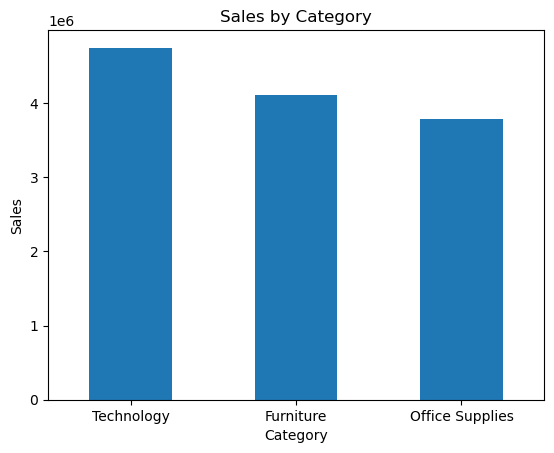

In [39]:
category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

## 3.3 Profit by Category

Sales alone aren't enough.<br>
A company can have high sales but low profit.

In [40]:
category_profit = (
    df_clean.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print(category_profit)

Category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          285204.72380
Name: Profit, dtype: float64


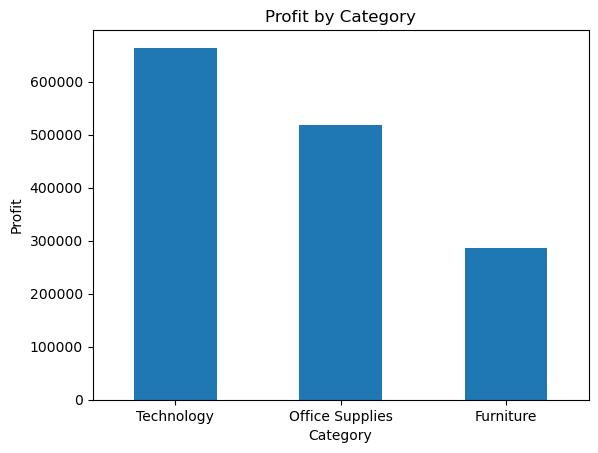

In [41]:
category_profit.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.show()

In [43]:
# SALES BY CATEGORY AND PROFIT BY CATEGORY

category_analysis = df_clean.groupby("Category").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
)

category_analysis["Profit_Margin_%"] = (
    category_analysis["Total_Profit"] /
    category_analysis["Total_Sales"] * 100
)

category_analysis = category_analysis.sort_values(
    "Total_Sales", ascending=False
)

category_analysis

,Total_Sales,Total_Profit,Profit_Margin_%
Category,,,
Technology,4.744557e+06,663778.73318,13.990319
Furniture,4.110874e+06,285204.72380,6.937812
Office Supplies,3.787070e+06,518473.83430,13.690632


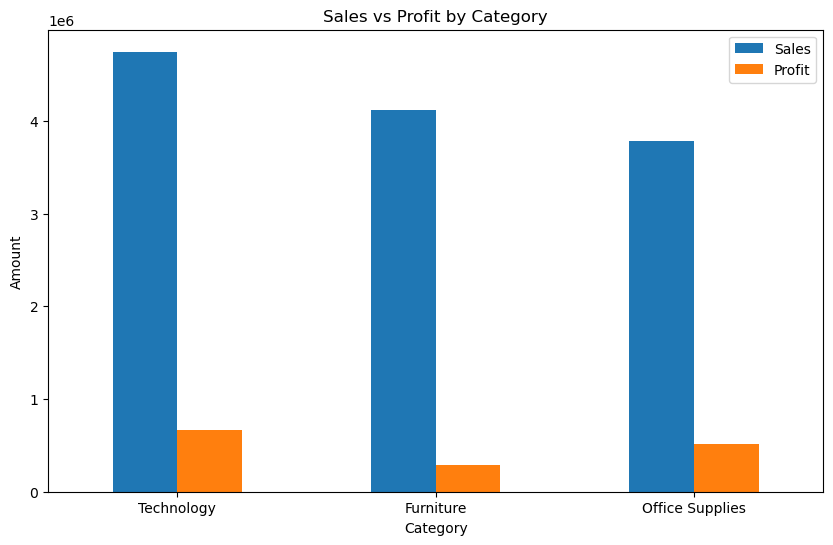

In [44]:
category_analysis[["Total_Sales", "Total_Profit"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sales vs Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.legend(["Sales", "Profit"])
plt.show()

> Furniture generates more revenue, but it isn't converting that revenue into profit as effectively as Office Supplies.
But don't conclude why yet. We need to investigate why.

In [45]:
category_analysis.sort_values(
    "Profit_Margin_%",
    ascending=False
)

,Total_Sales,Total_Profit,Profit_Margin_%
Category,,,
Technology,4.744557e+06,663778.73318,13.990319
Office Supplies,3.787070e+06,518473.83430,13.690632
Furniture,4.110874e+06,285204.72380,6.937812


In [46]:
# reason behind furniture having lower profit
discount_analysis = df_clean.groupby("Category").agg(
    Average_Discount=("Discount", "mean"),
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
)

discount_analysis["Profit_Margin_%"] = (
    discount_analysis["Total_Profit"] /
    discount_analysis["Total_Sales"] * 100
)

discount_analysis.sort_values("Average_Discount", ascending=False)

,Average_Discount,Total_Sales,Total_Profit,Profit_Margin_%
Category,,,,
Furniture,0.168087,4.110874e+06,285204.72380,6.937812
Office Supplies,0.137409,3.787070e+06,518473.83430,13.690632
Technology,0.135342,4.744557e+06,663778.73318,13.990319


In [48]:
# shopping costs
shipping_analysis = df_clean.groupby("Category").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Total_Shipping_Cost=("Shipping Cost", "sum")
)

shipping_analysis["Shipping_Cost_%"] = (
    shipping_analysis["Total_Shipping_Cost"] /
    shipping_analysis["Total_Sales"] * 100
)

shipping_analysis

,Total_Sales,Total_Profit,Total_Shipping_Cost,Shipping_Cost_%
Category,,,,
Furniture,4.110874e+06,285204.72380,440320.66,10.711120
Office Supplies,3.787070e+06,518473.83430,405451.29,10.706199
Technology,4.744557e+06,663778.73318,507048.74,10.686955


In [49]:
# sub category
subcategory_analysis = df_clean.groupby(
    ["Category", "Sub-Category"]
).agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Average_Discount=("Discount", "mean")
)

subcategory_analysis["Profit_Margin_%"] = (
    subcategory_analysis["Total_Profit"] /
    subcategory_analysis["Total_Sales"] * 100
)

subcategory_analysis.sort_values(
    "Total_Profit",
    ascending=True
)

Total_Sales  Total_Profit  Average_Discount  \
Category        Sub-Category                                                 
Furniture       Tables        7.570419e+05  -64083.38870          0.290732   
Office Supplies Fasteners     8.324232e+04   11525.42410          0.140595   
                Labels        7.340403e+04   15010.51200          0.120449   
                Supplies      2.430742e+05   22583.26310          0.127918   
                Envelopes     1.709043e+05   29601.11630          0.131749   
Furniture       Furnishings   3.855783e+05   46967.42550          0.151066   
Office Supplies Art           3.720920e+05   57953.91090          0.117362   
Technology      Machines      7.790601e+05   58867.87300          0.169583   
Office Supplies Paper         2.442917e+05   59207.68270          0.109469   
                Binders       4.619115e+05   72449.84600          0.179207   
                Storage       1.127086e+06  108461.48980          0.138464   
Technology      Accessories   7.492370e+05  129626.30620          0.120481   
Furniture       Chairs        1.501682e+06  140396.26750          0.163110   
Office Supplies Appliances    1.011064e+06  141680.58940          0.141709   
Furniture       Bookcases     1.466572e+06  161924.41950          0.153758   
Technology      Phones        1.706824e+06  216717.00580          0.145847   
                Copiers       1.509436e+06  258567.54818          0.117147   

                              Profit_Margin_%  
Category        Sub-Category                   
Furniture       Tables              -8.464972  
Office Supplies Fasteners           13.845631  
                Labels              20.449166  
                Supplies             9.290686  
                Envelopes           17.320287  
Furniture       Furnishings         12.181036  
Office Supplies Art                 15.575158  
Technology      Machines             7.556269  
Office Supplies Paper               24.236467  
                Binders             15.684789  
                Storage              9.623179  
Technology      Accessories         17.301108  
Furniture       Chairs               9.349269  
Office Supplies Appliances          14.013015  
Furniture       Bookcases           11.041012  
Technology      Phones              12.697091  
                Copiers             17.130074

<p>Tables are a significant profitability concern. Despite generating approximately 757K in sales, the sub-category recorded a loss of approximately 64K, resulting in a negative profit margin of 8.46%. The average discount for Tables was approximately 29%, substantially higher than several profitable sub-categories. This suggests that discounting may be contributing to the weak profitability and warrants further investigation.</p>

Region
Central           2.822303e+06
South             1.600907e+06
North             1.248166e+06
Oceania           1.100185e+06
Southeast Asia    8.844232e+05
North Asia        8.483098e+05
EMEA              8.061613e+05
Africa            7.837732e+05
Central Asia      7.528266e+05
West              7.254578e+05
East              6.787812e+05
Caribbean         3.242809e+05
Canada            6.692817e+04
Name: Sales, dtype: float64


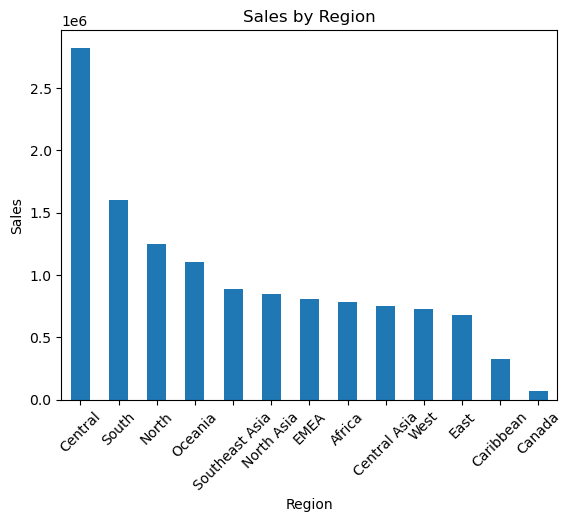

In [50]:
# Sales by Region
region_sales = (
    df_clean.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(region_sales)

# visualization of sales by region
region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

Region
Central           311403.98164
North             194597.95252
North Asia        165578.42100
South             140355.76618
Central Asia      132480.18700
Oceania           120089.11200
West              108418.44890
East               91522.78000
Africa             88871.63100
EMEA               43897.97100
Caribbean          34571.32104
Southeast Asia     17852.32900
Canada             17817.39000
Name: Profit, dtype: float64


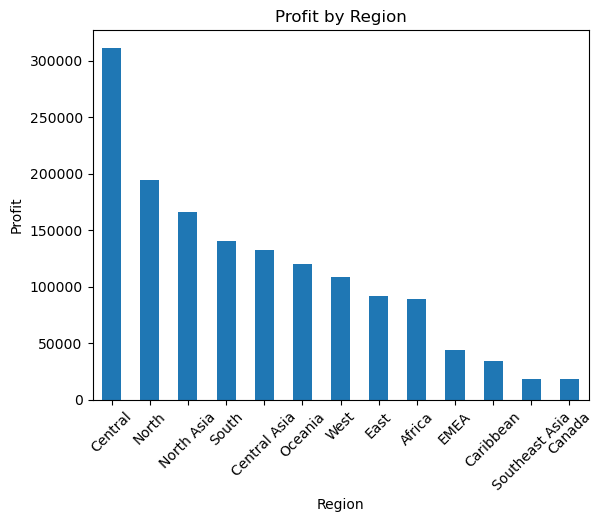

In [51]:
# profit by region
region_profit = (
    df_clean.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print(region_profit)

# visualization of profit by region
region_profit.plot(kind="bar")

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

In [52]:
region_analysis = df_clean.groupby("Region").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
)

region_analysis["Profit_Margin_%"] = (
    region_analysis["Total_Profit"] /
    region_analysis["Total_Sales"] * 100
)

region_analysis = region_analysis.sort_values(
    "Total_Sales", ascending=False
)

region_analysis

,Total_Sales,Total_Profit,Profit_Margin_%
Region,,,
Central,2.822303e+06,311403.98164,11.033685
South,1.600907e+06,140355.76618,8.767265
North,1.248166e+06,194597.95252,15.590716
Oceania,1.100185e+06,120089.11200,10.915360
Southeast Asia,8.844232e+05,17852.32900,2.018528
North Asia,8.483098e+05,165578.42100,19.518627
EMEA,8.061613e+05,43897.97100,5.445309
Africa,7.837732e+05,88871.63100,11.338947
Central Asia,7.528266e+05,132480.18700,17.597703


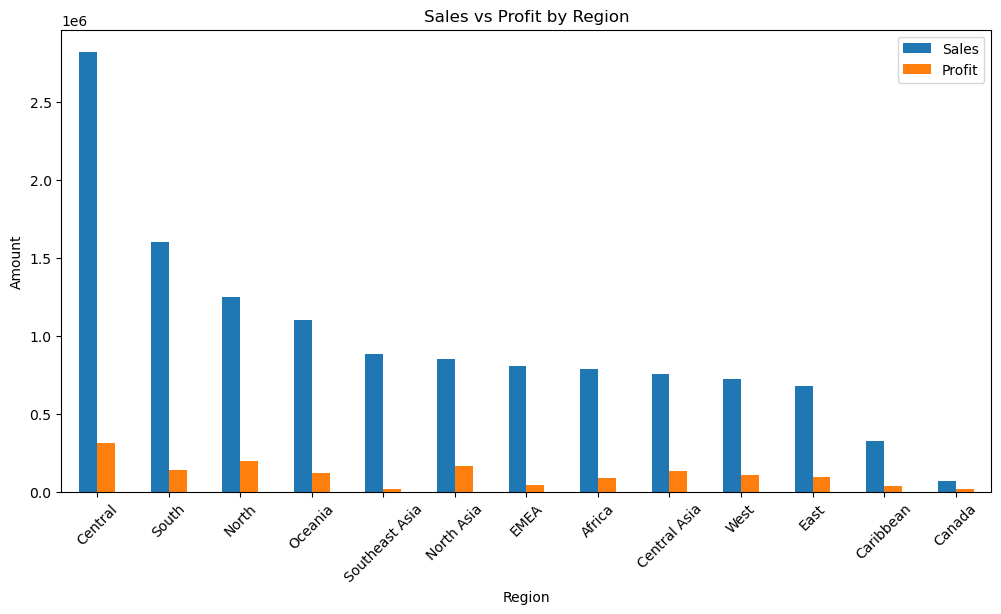

In [53]:
region_analysis[["Total_Sales", "Total_Profit"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Sales vs Profit by Region")
plt.xlabel("Region")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.legend(["Sales", "Profit"])
plt.show()

## 🧠 Our BA finding

For this project, we can record this as:<br>

> Finding 1 — Regional Profitability: Southeast Asia generates approximately 884K in sales but has a profit margin of only 2.02%, significantly lower than other regions such as North Asia (19.52%) and Central Asia (17.60%). This indicates that strong sales volume in Southeast Asia is not translating effectively into profitability and warrants further investigation.

But again — don't assume the reason.<br>

We need to investigate why Southeast Asia has such a low margin.<br>

Possible factors:<br>

> High discounts<br>
> High shipping costs<br>
> Loss-making products<br>
> Product mix<br>
> Specific countries<br>
> Specific categories<br>

In [54]:
region_analysis.sort_values(
    "Profit_Margin_%",
    ascending=False
)

,Total_Sales,Total_Profit,Profit_Margin_%
Region,,,
Canada,6.692817e+04,17817.39000,26.621660
North Asia,8.483098e+05,165578.42100,19.518627
Central Asia,7.528266e+05,132480.18700,17.597703
North,1.248166e+06,194597.95252,15.590716
West,7.254578e+05,108418.44890,14.944831
East,6.787812e+05,91522.78000,13.483399
Africa,7.837732e+05,88871.63100,11.338947
Central,2.822303e+06,311403.98164,11.033685
Oceania,1.100185e+06,120089.11200,10.915360


In [55]:
# investigation of the reason behind the low profit margin in the South region
sea_category = df_clean[
    df_clean["Region"] == "Southeast Asia"
].groupby("Category").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Average_Discount=("Discount", "mean"),
    Total_Shipping_Cost=("Shipping Cost", "sum")
)

sea_category["Profit_Margin_%"] = (
    sea_category["Total_Profit"] /
    sea_category["Total_Sales"] * 100
)

sea_category

,Total_Sales,Total_Profit,Average_Discount,Total_Shipping_Cost,Profit_Margin_%
Category,,,,,
Furniture,313386.7035,-7269.7665,0.247147,34592.93,-2.319743
Office Supplies,241285.0815,4173.2515,0.295990,26059.03,1.729594
Technology,329751.3840,20948.8440,0.234305,33023.88,6.352921


### Business Finding 2 — Southeast Asia Profitability

Southeast Asia generates approximately 884K in sales but has a low overall profit margin of 2.02%.

Furniture is the only loss-making category in the region, generating approximately 313K in sales but a loss of approximately 7.3K, resulting in a -2.32% profit margin.

This indicates that Furniture is a key area contributing to the region's weak profitability and requires further investigation at the sub-category and product levels.

In [57]:
# investigate the countries
sea_country = df_clean[
    df_clean["Region"] == "Southeast Asia"
].groupby("Country").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
)

sea_country["Profit_Margin_%"] = (
    sea_country["Total_Profit"] /
    sea_country["Total_Sales"] * 100
)

sea_country.sort_values(
    "Profit_Margin_%",
    ascending=True
)

,Total_Sales,Total_Profit,Profit_Margin_%
Country,,,
Thailand,77051.9550,-7308.1950,-9.484763
Philippines,183420.1650,-16128.2250,-8.793049
Myanmar (Burma),34138.8717,-2109.2583,-6.178465
Vietnam,65800.1994,-1870.2306,-2.842287
Indonesia,404887.4979,15608.6779,3.855065
Singapore,40286.2500,8853.0600,21.975389
Cambodia,17476.0200,4476.5400,25.615329
Malaysia,61362.2100,16329.9600,26.612405


### Business Finding 3 — Country-level Profitability in Southeast Asia

Southeast Asia's low profitability is concentrated in specific countries rather than being uniform across the region.

Thailand, the Philippines, Myanmar, and Vietnam are loss-making, while Singapore, Cambodia, and Malaysia generate positive profit margins.

The Philippines records the largest absolute loss at approximately 16.1K, while Thailand has the lowest profit margin at approximately -9.48%.

This indicates that country-level factors should be investigated rather than applying a single strategy across the entire Southeast Asian region.

## One important thing before we continue

We have now found two potential business problems:<br>

### Problem 1 — Furniture

Globally:

> Furniture has relatively strong sales but significantly weaker profitability than Technology.

And within Southeast Asia:

Furniture is loss-making.

### Problem 2 — Southeast Asia

> The region has only a 2.02% overall profit margin, with losses concentrated in Thailand, Philippines, Myanmar and Vietnam.

In [58]:
# monthly analysis
monthly_analysis = df_clean.groupby(
    df_clean["Order Date"].dt.to_period("M")
).agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
)

monthly_analysis.head()

,Total_Sales,Total_Profit
Order Date,,
2011-01,98898.48886,8321.80096
2011-02,91152.15698,12417.90698
2011-03,145729.36736,15303.56826
2011-04,116915.76418,12902.32438
2011-05,146747.83610,12183.82870


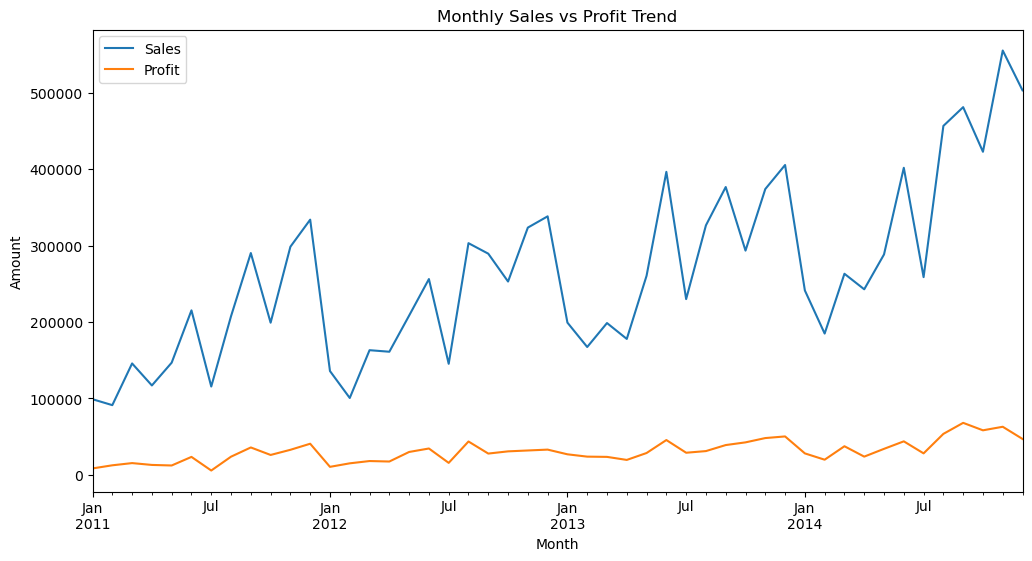

In [59]:
# visualization of monthly analysis
monthly_analysis[["Total_Sales", "Total_Profit"]].plot(
    kind="line",
    figsize=(12, 6)
)

plt.title("Monthly Sales vs Profit Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.legend(["Sales", "Profit"])
plt.show()

### Business Finding 4 — Sales and Profit Trend

The analysis shows an overall upward trend in sales and profit over the study period. However, both metrics exhibit significant month-to-month fluctuations, with several sharp increases and declines.

The growth in sales is generally accompanied by growth in profit, but the variability suggests that certain periods may have stronger demand or profitability than others. Further analysis of monthly and seasonal patterns can help identify periods of consistently strong or weak performance.

In [60]:
# monthly seasonality
monthly_seasonality = df_clean.groupby(
    df_clean["Order Date"].dt.month
).agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
)
monthly_seasonality

,Total_Sales,Total_Profit
Order Date,,
1,6.751337e+05,73535.38454
2,5.437394e+05,70932.19922
3,7.705009e+05,94087.52096
4,6.985612e+05,73513.63124
5,9.040123e+05,104509.78428
6,1.269717e+06,147079.41684
7,7.493818e+05,78070.09172
8,1.293833e+06,151854.10972
9,1.437380e+06,170438.18316


In [61]:
# giving names to the index for better understanding
monthly_seasonality.index = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_seasonality

,Total_Sales,Total_Profit
January,6.751337e+05,73535.38454
February,5.437394e+05,70932.19922
March,7.705009e+05,94087.52096
April,6.985612e+05,73513.63124
May,9.040123e+05,104509.78428
June,1.269717e+06,147079.41684
July,7.493818e+05,78070.09172
August,1.293833e+06,151854.10972
September,1.437380e+06,170438.18316
October,1.168184e+06,157269.35838


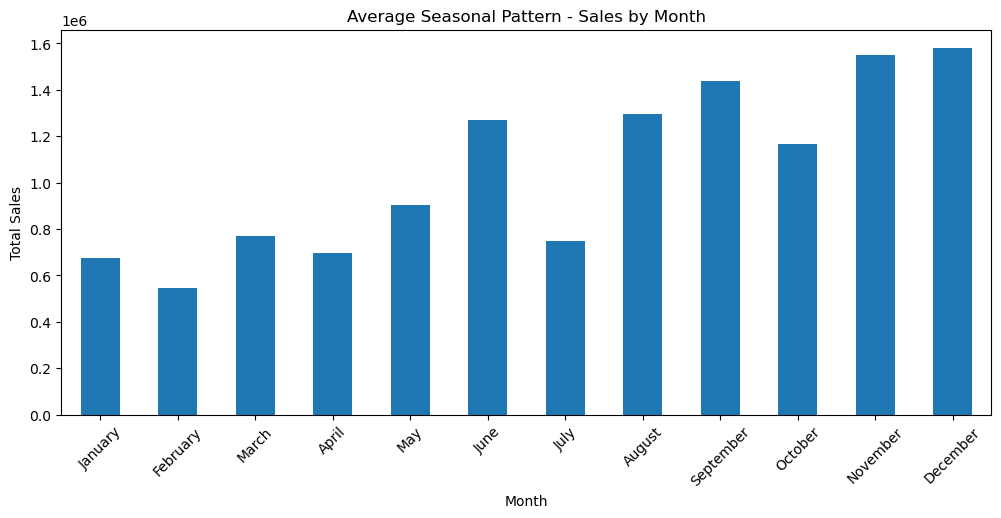

In [62]:
# visualization 
monthly_seasonality["Total_Sales"].plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Average Seasonal Pattern - Sales by Month")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

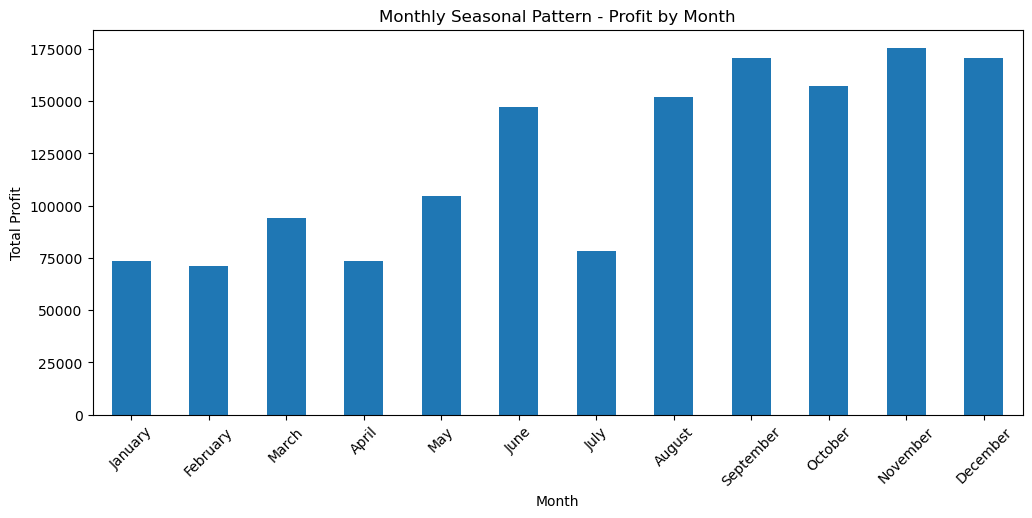

In [63]:
monthly_seasonality["Total_Profit"].plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Monthly Seasonal Pattern - Profit by Month")
plt.xlabel("Month")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.show()

### Business Finding 5 — Seasonal Sales Pattern

Sales and profit show a clear seasonal pattern, with stronger performance generally occurring during the second half of the year.

November and December record the highest sales at approximately 1.55M and 1.58M respectively. November generates the highest monthly profit at approximately 175.4K, despite December having slightly higher sales.

January, February, and April are relatively weaker sales months.

This pattern can help the business plan inventory, marketing campaigns, staffing, and other resources around periods of higher demand.

# Discount Analysis

In [64]:
discount_category = df_clean.groupby("Category").agg(
    Average_Discount=("Discount", "mean"),
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
)

discount_category["Profit_Margin_%"] = (
    discount_category["Total_Profit"] /
    discount_category["Total_Sales"] * 100
)

discount_category

,Average_Discount,Total_Sales,Total_Profit,Profit_Margin_%
Category,,,,
Furniture,0.168087,4.110874e+06,285204.72380,6.937812
Office Supplies,0.137409,3.787070e+06,518473.83430,13.690632
Technology,0.135342,4.744557e+06,663778.73318,13.990319


In [65]:
discount_subcategory = df_clean.groupby(
    ["Category", "Sub-Category"]
).agg(
    Average_Discount=("Discount", "mean"),
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
)

discount_subcategory["Profit_Margin_%"] = (
    discount_subcategory["Total_Profit"] /
    discount_subcategory["Total_Sales"] * 100
)

discount_subcategory.sort_values(
    "Average_Discount",
    ascending=False
)

Average_Discount   Total_Sales  Total_Profit  \
Category        Sub-Category                                                 
Furniture       Tables                0.290732  7.570419e+05  -64083.38870   
Office Supplies Binders               0.179207  4.619115e+05   72449.84600   
Technology      Machines              0.169583  7.790601e+05   58867.87300   
Furniture       Chairs                0.163110  1.501682e+06  140396.26750   
                Bookcases             0.153758  1.466572e+06  161924.41950   
                Furnishings           0.151066  3.855783e+05   46967.42550   
Technology      Phones                0.145847  1.706824e+06  216717.00580   
Office Supplies Appliances            0.141709  1.011064e+06  141680.58940   
                Fasteners             0.140595  8.324232e+04   11525.42410   
                Storage               0.138464  1.127086e+06  108461.48980   
                Envelopes             0.131749  1.709043e+05   29601.11630   
                Supplies              0.127918  2.430742e+05   22583.26310   
Technology      Accessories           0.120481  7.492370e+05  129626.30620   
Office Supplies Labels                0.120449  7.340403e+04   15010.51200   
                Art                   0.117362  3.720920e+05   57953.91090   
Technology      Copiers               0.117147  1.509436e+06  258567.54818   
Office Supplies Paper                 0.109469  2.442917e+05   59207.68270   

                              Profit_Margin_%  
Category        Sub-Category                   
Furniture       Tables              -8.464972  
Office Supplies Binders             15.684789  
Technology      Machines             7.556269  
Furniture       Chairs               9.349269  
                Bookcases           11.041012  
                Furnishings         12.181036  
Technology      Phones              12.697091  
Office Supplies Appliances          14.013015  
                Fasteners           13.845631  
                Storage              9.623179  
                Envelopes           17.320287  
                Supplies             9.290686  
Technology      Accessories         17.301108  
Office Supplies Labels              20.449166  
                Art                 15.575158  
Technology      Copiers             17.130074  
Office Supplies Paper               24.236467

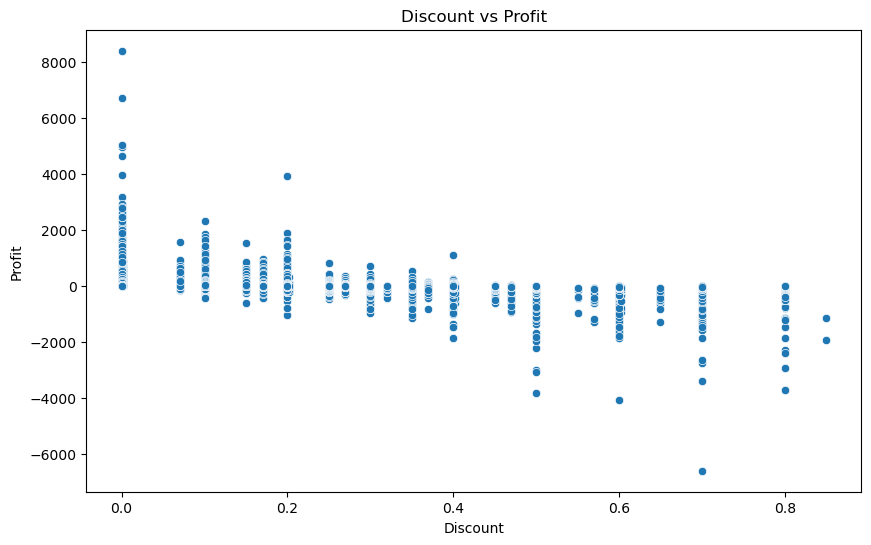

In [66]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="Discount",
    y="Profit"
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

### The graph shows association, not causation.

> The analysis indicates a negative relationship between discount level and profitability. Higher discount levels are associated with a greater concentration of loss-making transactions.

In [67]:
df_clean[["Discount", "Profit"]].corr()

,Discount,Profit
Discount,1.00000,-0.31649
Profit,-0.31649,1.00000


### Business Finding 6 — Discount and Profitability

The correlation analysis shows a negative relationship between discount and profit, with a correlation coefficient of -0.31649.

This indicates that higher discount levels are generally associated with lower profitability. However, correlation does not establish causation, so other factors such as product category, shipping costs, and region should also be considered when evaluating the impact of discounts on profit.

The relationship suggests that the company's discount strategy should be reviewed, particularly for products or regions that are already generating low or negative margins.

In [69]:
df_clean["Discount_Band"] = pd.cut(
    df_clean["Discount"],
    bins=[-0.01, 0.10, 0.20, 0.30, 0.40, 0.50, 1.00],
    labels=[
        "0-10%",
        "10-20%",
        "20-30%",
        "30-40%",
        "40-50%",
        "50%+"
    ]
)

In [70]:
discount_band_analysis = df_clean.groupby(
    "Discount_Band",
    observed=True
).agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Average_Profit=("Profit", "mean"),
    Number_of_Orders=("Order ID", "nunique")
)

discount_band_analysis["Profit_Margin_%"] = (
    discount_band_analysis["Total_Profit"] /
    discount_band_analysis["Total_Sales"] * 100
)

discount_band_analysis

,Total_Sales,Total_Profit,Average_Profit,Number_of_Orders,Profit_Margin_%
Discount_Band,,,,,
0-10%,8.955030e+06,2.108885e+06,62.600467,17154,23.549721
10-20%,1.757261e+06,1.732548e+05,27.614734,4363,9.859367
20-30%,3.825547e+05,-2.115561e+04,-21.877573,843,-5.530089
30-40%,7.013431e+05,-1.661154e+05,-48.857485,2074,-23.685332
40-50%,4.746883e+05,-2.148294e+05,-77.027382,1758,-45.256933
50%+,3.716247e+05,-4.125817e+05,-98.893015,2369,-111.021065


In [72]:
discount_band_analysis

,Total_Sales,Total_Profit,Average_Profit,Number_of_Orders,Profit_Margin_%
Discount_Band,,,,,
0-10%,8.955030e+06,2.108885e+06,62.600467,17154,23.549721
10-20%,1.757261e+06,1.732548e+05,27.614734,4363,9.859367
20-30%,3.825547e+05,-2.115561e+04,-21.877573,843,-5.530089
30-40%,7.013431e+05,-1.661154e+05,-48.857485,2074,-23.685332
40-50%,4.746883e+05,-2.148294e+05,-77.027382,1758,-45.256933
50%+,3.716247e+05,-4.125817e+05,-98.893015,2369,-111.021065


### Business Finding 6 — Discount Impact on Profitability

Discount level has a clear negative relationship with profitability.

Transactions with discounts between 0–10% generate approximately 23.55% profit margin, while discounts between 10–20% generate a 9.86% margin.

From the 20–30% discount range onward, the overall profit margin becomes negative. The 50%+ discount band records a particularly severe -111.02% profit margin.

The correlation between Discount and Profit is -0.31649, supporting the observed negative relationship.

This suggests that aggressive discounting should be carefully reviewed, particularly for products and regions that already have weak profitability. However, discount alone cannot be considered the sole cause of losses because other factors such as product mix, shipping costs, and regional performance may also contribute.

# Customer Analysis

In [73]:
customer_analysis = df_clean.groupby("Customer Name").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Total_Orders=("Order ID", "nunique")
)

customer_analysis["Profit_Margin_%"] = (
    customer_analysis["Total_Profit"] /
    customer_analysis["Total_Sales"] * 100
)

customer_analysis.sort_values(
    "Total_Sales",
    ascending=False
).head(10)

,Total_Sales,Total_Profit,Total_Orders,Profit_Margin_%
Customer Name,,,,
Tom Ashbrook,40488.07080,6311.97910,30,15.589726
Tamara Chand,37457.33300,8672.89890,36,23.154075
Greg Tran,35550.95428,5214.13118,34,14.666642
Christopher Conant,35187.07640,5603.33370,39,15.924408
Sean Miller,35170.93296,-409.70634,28,-1.164900
Bart Watters,32310.44650,3595.88590,45,11.129174
Natalie Fritzler,31781.25850,1542.82110,43,4.854500
Fred Hopkins,30400.67452,4609.29112,39,15.161805
Jane Waco,30288.45030,6265.84570,40,20.687244


> High sales do not necessarily mean high customer value. Customer profitability should be evaluated alongside sales volume.

In [74]:
customer_analysis.sort_values(
    "Total_Profit",
    ascending=False
).head(10)

,Total_Sales,Total_Profit,Total_Orders,Profit_Margin_%
Customer Name,,,,
Tamara Chand,37457.33300,8672.89890,36,23.154075
Raymond Buch,29602.14260,8453.04950,29,28.555533
Sanjit Chand,26521.13200,8205.37990,35,30.939026
Hunter Lopez,30243.56658,7816.56778,24,25.845390
Bill Eplett,28479.16740,7410.00530,42,26.019038
Harry Marie,28476.93760,6958.28640,41,24.434813
Susan Pistek,29020.60386,6484.40726,32,22.344150
Mike Gockenbach,23377.07220,6458.67620,27,27.628251
Adrian Barton,25123.18000,6417.28450,40,25.543281


In [75]:
customer_analysis.sort_values(
    "Total_Profit",
    ascending=True
).head(10)

,Total_Sales,Total_Profit,Total_Orders,Profit_Margin_%
Customer Name,,,,
Cindy Stewart,13429.74640,-6151.55810,23,-45.805467
Luke Foster,13421.23850,-3644.34750,27,-27.153586
Grant Thornton,20225.35784,-3577.92306,27,-17.690283
Candace McMahon,14794.67440,-2798.79060,28,-18.917555
Skye Norling,14218.81400,-2637.98050,31,-18.552746
Denise Monton,22053.31050,-2597.80290,33,-11.779650
Sharelle Roach,13002.45694,-2551.18846,24,-19.620818
David Bremer,6273.82662,-2270.69658,20,-36.193168
Sean Braxton,20513.93680,-1896.97930,27,-9.247271


### Business Finding 7 — Customer Profitability

Customer-level analysis shows that high sales do not always translate into high profitability.

Several customers generate substantial sales while recording negative profit. Cindy Stewart is the most notable example among the identified loss-making customers, generating approximately 13.4K in sales but a loss of approximately 6.15K, resulting in a -45.81% profit margin.

This indicates that customer value should be evaluated using both revenue and profitability rather than sales alone. Loss-making customer accounts should be further investigated at the order and product level to identify factors such as excessive discounts, product mix, or shipping costs.

# Product Analysis

In [76]:
product_analysis = df_clean.groupby("Product Name").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Total_Quantity=("Quantity", "sum")
)

product_analysis["Profit_Margin_%"] = (
    product_analysis["Total_Profit"] /
    product_analysis["Total_Sales"] * 100
)

product_analysis.sort_values(
    "Total_Sales",
    ascending=False
).head(10)

,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_%
Product Name,,,,
"Apple Smart Phone, Full Size",86935.7786,5921.5786,171,6.811440
"Cisco Smart Phone, Full Size",76441.5306,17238.5206,139,22.551250
"Motorola Smart Phone, Full Size",73156.3030,17027.1130,134,23.274977
"Nokia Smart Phone, Full Size",71904.5555,9938.1955,147,13.821371
Canon imageCLASS 2200 Advanced Copier,61599.8240,25199.9280,20,40.909091
"Hon Executive Leather Armchair, Adjustable",58193.4841,5997.2541,169,10.305714
"Office Star Executive Leather Armchair, Adjustable",50661.6840,4710.9840,141,9.298909
"Harbour Creations Executive Leather Armchair, Adjustable",50121.5160,10427.3260,142,20.804091
"Samsung Smart Phone, Cordless",48653.4600,-198.0900,108,-0.407145


In [77]:
# top products by profit
product_analysis.sort_values(
    "Total_Profit",
    ascending=False
).head(10)

,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_%
Product Name,,,,
Canon imageCLASS 2200 Advanced Copier,61599.8240,25199.9280,20,40.909091
"Cisco Smart Phone, Full Size",76441.5306,17238.5206,139,22.551250
"Motorola Smart Phone, Full Size",73156.3030,17027.1130,134,23.274977
"Hoover Stove, Red",31663.7790,11807.9690,62,37.291724
"Sauder Classic Bookcase, Traditional",39108.3030,10672.0730,113,27.288510
"Harbour Creations Executive Leather Armchair, Adjustable",50121.5160,10427.3260,142,20.804091
"Nokia Smart Phone, Full Size",71904.5555,9938.1955,147,13.821371
"Cisco Smart Phone, with Caller ID",43127.5008,9786.6408,85,22.692344
"Nokia Smart Phone, with Caller ID",47877.7857,9465.3257,96,19.769765


In [78]:
# worst products by profit
product_analysis.sort_values(
    "Total_Profit",
    ascending=True
).head(10)

,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_%
Product Name,,,,
Cubify CubeX 3D Printer Double Head Print,11099.9630,-8879.9704,9,-80.000000
Lexmark MX611dhe Monochrome Laser Printer,16829.9010,-4589.9730,18,-27.272727
"Motorola Smart Phone, Cordless",38931.0420,-4447.0380,74,-11.422859
Cubify CubeX 3D Printer Triple Head Print,7999.9800,-3839.9904,4,-48.000000
"Bevis Round Table, Adjustable Height",5654.7960,-3649.8940,22,-64.545105
"Bevis Computer Table, Fully Assembled",11177.8962,-3509.5638,43,-31.397355
"Rogers Lockers, Blue",28214.5892,-2893.4908,167,-10.255300
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.6400,-2876.1156,27,-29.000000
"Bevis Wood Table, with Bottom Storage",11134.6620,-2782.5880,34,-24.990323


### Business Finding 8 — Product-Level Profitability

Product-level analysis shows significant variation in profitability. Some products generate strong sales and high profit margins, while others generate substantial losses.

The Cubify CubeX 3D Printer Double Head Print is the largest loss-making product among the analyzed products, generating approximately 11.1K in sales but a loss of approximately 8.9K, resulting in an -80% profit margin.

Several loss-making products also belong to the Tables sub-category, including Bevis Round Table, Bevis Computer Table, Chromcraft Conference Tables, Bevis Wood Table, and Lesro Training Table.

This reinforces the earlier finding that the Tables sub-category requires further investigation into pricing, discounting, product costs, and sales strategy.